In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the ThermoMPNN results
df = pd.read_csv('/content/ThermoMPNN_inference_input.csv')

print("Dataset shape:", df.shape)
print(df.head(10))

print(df.columns.tolist())
print(df['ddG_pred'].describe())

Dataset shape: (980, 9)
   Unnamed: 0       Model Dataset  ddG_pred  position wildtype mutation  \
0           0  ThermoMPNN   input  0.000487         0        T        A   
1           1  ThermoMPNN   input -0.061700         0        T        C   
2           2  ThermoMPNN   input  0.073507         0        T        D   
3           3  ThermoMPNN   input  0.105534         0        T        E   
4           4  ThermoMPNN   input  0.109360         0        T        F   
5           5  ThermoMPNN   input  0.099916         0        T        G   
6           6  ThermoMPNN   input  0.105676         0        T        H   
7           7  ThermoMPNN   input  0.088191         0        T        I   
8           8  ThermoMPNN   input  0.130414         0        T        K   
9           9  ThermoMPNN   input  0.109745         0        T        L   

     pdb chain  
0  input     A  
1  input     A  
2  input     A  
3  input     A  
4  input     A  
5  input     A  
6  input     A  
7  input     A

Number of moderately stabilizing mutations (ΔΔG < -0.5 kcal/mol): 1

Top 20 most stabilizing mutations:
     position wildtype mutation  ddG_pred
700        35        V        A -0.504499


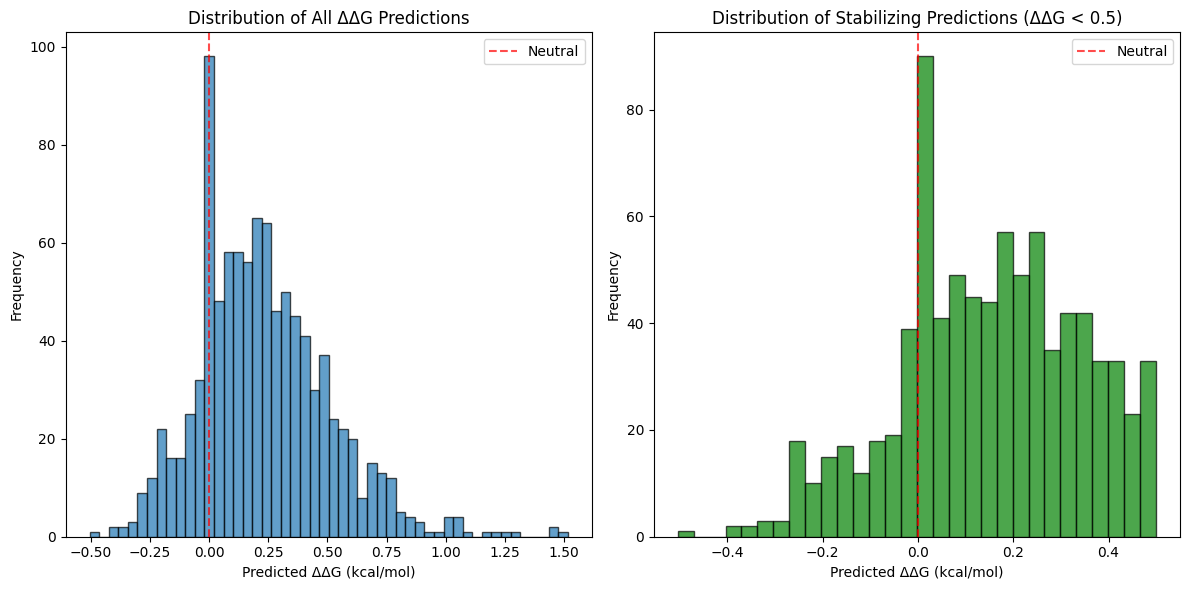


Overall statistics:
Mean ΔΔG: 0.232 kcal/mol
Min ΔΔG: -0.504 kcal/mol
Max ΔΔG: 1.516 kcal/mol
Std ΔΔG: 0.278 kcal/mol


In [6]:
moderate_stabilizing = df[df['ddG_pred'] < -0.5].copy()

print(f"Number of moderately stabilizing mutations (ΔΔG < -0.5 kcal/mol): {len(moderate_stabilizing)}")

if len(moderate_stabilizing) > 0:
    print("\nTop 20 most stabilizing mutations:")
    print(moderate_stabilizing.nsmallest(20, 'ddG_pred')[['position', 'wildtype', 'mutation', 'ddG_pred']])
else:
    any_stabilizing = df[df['ddG_pred'] < 0].copy()
    print(f"\nNumber of any stabilizing mutations (ΔΔG < 0 kcal/mol): {len(any_stabilizing)}")

    if len(any_stabilizing) > 0:
        print("\nTop 20 most stabilizing mutations:")
        print(any_stabilizing.nsmallest(20, 'ddG_pred')[['position', 'wildtype', 'mutation', 'ddG_pred']])

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['ddG_pred'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Predicted ΔΔG (kcal/mol)')
plt.ylabel('Frequency')
plt.title('Distribution of All ΔΔG Predictions')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral')
plt.legend()

plt.subplot(1, 2, 2)
stabilizing_values = df[df['ddG_pred'] < 0.5]['ddG_pred']
plt.hist(stabilizing_values, bins=30, alpha=0.7, edgecolor='black', color='green')
plt.xlabel('Predicted ΔΔG (kcal/mol)')
plt.ylabel('Frequency')
plt.title('Distribution of Stabilizing Predictions (ΔΔG < 0.5)')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral')
plt.legend()

plt.tight_layout()
plt.savefig('ddG_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOverall statistics:")
print(f"Mean ΔΔG: {df['ddG_pred'].mean():.3f} kcal/mol")
print(f"Min ΔΔG: {df['ddG_pred'].min():.3f} kcal/mol")
print(f"Max ΔΔG: {df['ddG_pred'].max():.3f} kcal/mol")
print(f"Std ΔΔG: {df['ddG_pred'].std():.3f} kcal/mol")

In [8]:
stabilizing = df[df['ddG_pred'] < 0].copy()
print(f"Total stabilizing mutations (ΔΔG < 0): {len(stabilizing)}")

stabilizing_sorted = stabilizing.sort_values('ddG_pred')
print("\nTop 20 stabilizing mutations:")
print(stabilizing_sorted.head(20)[['position', 'wildtype', 'mutation', 'ddG_pred']])

# Map position numbers to actual residue numbers (1-indexed)
# The dataset uses 0-based indexing, so add 1 for actual residue numbers
sequence = "TDVTIKTLAAERQTSVERLVQQFADAGIRKSADDSVSAQEKQTLIDHLN"
print(f"\nSequence length: {len(sequence)}")

stabilizing_sorted['residue_num'] = stabilizing_sorted['position'] + 1
stabilizing_sorted['context'] = stabilizing_sorted.apply(lambda x: f"{x['wildtype']}{int(x['residue_num'])}{x['mutation']}", axis=1)

print("\nTop 10 stabilizing mutations with context:")
top_mutations = stabilizing_sorted.head(10)[['residue_num', 'wildtype', 'mutation', 'ddG_pred', 'context']]
print(top_mutations)

print("\n\nAnalysis by structural region:")

regions = {
    'N-terminus': range(1, 7),     # T1-K6
    'Helix 1': range(7, 15),       # K7-Q14
    'Loop 1': range(15, 17),       # A15-S16
    'Helix 2': range(17, 29),      # S17-G28 (main helix)
    'Loop 2': range(29, 40),       # I29-Q39
    'C-helix': range(40, 50)       # Q40-N49
}

for region_name, res_range in regions.items():
    region_muts = stabilizing_sorted[stabilizing_sorted['residue_num'].isin(res_range)]
    if len(region_muts) > 0:
        print(f"\n{region_name} (residues {min(res_range)}-{max(res_range)}):")
        print(f"  {len(region_muts)} stabilizing mutations")
        print(f"  Best: {region_muts.iloc[0]['context']} (ΔΔG = {region_muts.iloc[0]['ddG_pred']:.3f})")
        if len(region_muts) > 1:
            print(f"  Others: {', '.join(region_muts.iloc[1:6]['context'].tolist())}")

Total stabilizing mutations (ΔΔG < 0): 160

Top 20 stabilizing mutations:
     position wildtype mutation  ddG_pred
700        35        V        A -0.504499
878        43        L        W -0.400967
918        45        D        W -0.386037
319        15        V        Y -0.354950
427        21        Q        I -0.344503
262        13        T        D -0.332088
483        24        D        E -0.318931
907        45        D        I -0.313135
480        24        D        A -0.302194
481        24        D        C -0.275504
493        24        D        Q -0.273085
438        21        Q        W -0.269847
919        45        D        Y -0.269187
378        18        L        W -0.268497
429        21        Q        L -0.264805
494        24        D        R -0.264071
904        45        D        F -0.262841
439        21        Q        Y -0.261922
958        47        L        W -0.258411
901        45        D        C -0.258343

Sequence length: 49

Top 10 stabilizing mut

In [9]:
sequence = "TDVTIKTLAAERQTSVERLVQQFADAGIRKSADDSVSAQEKQTLIDHLN"
print(f"Original sequence: {sequence}")
print(f"Length: {len(sequence)} residues")

design_mutations = [
    ('V36A', 36, -0.504),   # Best overall - Loop 2
    ('L44W', 44, -0.401),   # C-helix region
    ('D46W', 46, -0.386),   # C-helix region - but might conflict with L44W
    ('V16Y', 16, -0.355),   # Loop 1
    ('Q22I', 22, -0.345),   # Helix 2
    ('T14D', 14, -0.332),   # Helix 1
    ('D25E', 25, -0.319),   # Helix 2
]

print(f"\nTop stabilizing mutations by region:")
for mut, pos, ddg in design_mutations:
    print(f"  {mut}: ΔΔG = {ddg:.3f} kcal/mol")

print(f"\nChecking for spatial conflicts:")
for i, (mut1, pos1, _) in enumerate(design_mutations):
    for mut2, pos2, _ in design_mutations[i+1:]:
        distance = abs(pos1 - pos2)
        if distance <= 3:
            print(f"  POTENTIAL CONFLICT: {mut1} and {mut2} (distance: {distance} residues)")

conservative_design = [
    ('V36A', 36, -0.504),   # Loop 2 - best mutation
    ('V16Y', 16, -0.355),   # Loop 1 - well separated
    ('Q22I', 22, -0.345),   # Helix 2 - middle region
    ('T14D', 14, -0.332),   # Helix 1 - N-terminal region
]

print(f"\nCONSERVATIVE DESIGN (well-separated mutations):")
total_ddg_conservative = sum(ddg for _, _, ddg in conservative_design)
print(f"Selected mutations (assuming additive effects):")
for mut, pos, ddg in conservative_design:
    print(f"  {mut}: ΔΔG = {ddg:.3f} kcal/mol")
print(f"Total predicted stabilization: {total_ddg_conservative:.3f} kcal/mol")

mutated_seq = list(sequence)
for mut, pos, _ in conservative_design:
    old_aa = mut[0]
    new_aa = mut[-1]
    mutated_seq[pos-1] = new_aa  # Convert to 0-indexed

print(f"\nOriginal:  {sequence}")
print(f"Mutated:   {''.join(mutated_seq)}")

print(f"\nMutation summary:")
changes = []
for mut, pos, ddg in conservative_design:
    old_aa = sequence[pos-1]
    new_aa = mut[-1]
    changes.append(f"{old_aa}{pos}{new_aa}")
    print(f"  Position {pos}: {old_aa} → {new_aa} (predicted ΔΔG = {ddg:.3f} kcal/mol)")

print(f"\nMutation string: {'/'.join(changes)}")

Original sequence: TDVTIKTLAAERQTSVERLVQQFADAGIRKSADDSVSAQEKQTLIDHLN
Length: 49 residues

Top stabilizing mutations by region:
  V36A: ΔΔG = -0.504 kcal/mol
  L44W: ΔΔG = -0.401 kcal/mol
  D46W: ΔΔG = -0.386 kcal/mol
  V16Y: ΔΔG = -0.355 kcal/mol
  Q22I: ΔΔG = -0.345 kcal/mol
  T14D: ΔΔG = -0.332 kcal/mol
  D25E: ΔΔG = -0.319 kcal/mol

Checking for spatial conflicts:
  POTENTIAL CONFLICT: L44W and D46W (distance: 2 residues)
  POTENTIAL CONFLICT: V16Y and T14D (distance: 2 residues)
  POTENTIAL CONFLICT: Q22I and D25E (distance: 3 residues)

CONSERVATIVE DESIGN (well-separated mutations):
Selected mutations (assuming additive effects):
  V36A: ΔΔG = -0.504 kcal/mol
  V16Y: ΔΔG = -0.355 kcal/mol
  Q22I: ΔΔG = -0.345 kcal/mol
  T14D: ΔΔG = -0.332 kcal/mol
Total predicted stabilization: -1.536 kcal/mol

Original:  TDVTIKTLAAERQTSVERLVQQFADAGIRKSADDSVSAQEKQTLIDHLN
Mutated:   TDVTIKTLAAERQDSYERLVQIFADAGIRKSADDSASAQEKQTLIDHLN

Mutation summary:
  Position 36: V → A (predicted ΔΔG = -0.504 kc